In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
%matplotlib inline

from skimage.io import imread, imshow
from skimage.transform import resize

# Don't Show Warning Messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import pandas as pd
import kagglehub

# 1. DOWNLOAD (This stays the same)
path = kagglehub.dataset_download("vbookshelf/synthetic-cell-images-and-masks-bbbc005-v1")

# 2. UPDATE PATHS (The Kaggle code uses ../input/, but you must use the kagglehub path)
# Note: The double folder structure is common in this specific dataset
image_dir = os.path.join(path, "BBBC005_v1_images", "BBBC005_v1_images")
mask_dir = os.path.join(path, "BBBC005_v1_ground_truth", "BBBC005_v1_ground_truth")

# 3. GET LISTS (Modified to use your actual directories)
img_list = os.listdir(image_dir)
mask_list = os.listdir(mask_dir)

# 4. CREATE DATAFRAME
df_images = pd.DataFrame(img_list, columns=['image_id'])
df_images = df_images[df_images['image_id'] != '.htaccess']

# 5. KAGGLE LOGIC (Exactly as provided in your snippet)
def get_num_cells(x):
    a = x.split('_')
    b = a[2] # e.g. C53
    return int(b[1:])

df_images['num_cells'] = df_images['image_id'].apply(get_num_cells)

def check_for_mask(x):
    return 'yes' if x in mask_list else 'no'

df_images['has_mask'] = df_images['image_id'].apply(check_for_mask)

def get_blur_amt(x):
    a = x.split('_')
    b = a[3] # e.g. F1
    return int(b[1:])

df_images['blur_amt'] = df_images['image_id'].apply(get_blur_amt)

# 6. VERIFY
print(df_images.head())

100%|██████████| 3.55G/3.55G [00:27<00:00, 140MB/s]

Extracting files...


                              image_id  num_cells has_mask  blur_amt
0   SIMCEPImages_C06_C23_F7_s12_w2.TIF         23       no         7
1  SIMCEPImages_K11_C44_F32_s23_w2.TIF         44       no        32
2  SIMCEPImages_L13_C53_F35_s14_w1.TIF         53       no        35
3  SIMCEPImages_G21_C87_F20_s25_w2.TIF         87       no        20
4  SIMCEPImages_J06_C23_F29_s06_w1.TIF         23       no        29


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 1

NUM_TEST_IMAGES = 10

In [ ]:
df_images.head(10)


,image_id,num_cells,has_mask,blur_amt
0,SIMCEPImages_C06_C23_F7_s12_w2.TIF,23,no,7
1,SIMCEPImages_K11_C44_F32_s23_w2.TIF,44,no,32
2,SIMCEPImages_L13_C53_F35_s14_w1.TIF,53,no,35
3,SIMCEPImages_G21_C87_F20_s25_w2.TIF,87,no,20
4,SIMCEPImages_J06_C23_F29_s06_w1.TIF,23,no,29
5,SIMCEPImages_C23_C96_F7_s23_w1.TIF,96,no,7
6,SIMCEPImages_O03_C10_F45_s13_w2.TIF,10,no,45
7,SIMCEPImages_B16_C66_F4_s19_w1.TIF,66,no,4
8,SIMCEPImages_J17_C70_F29_s15_w2.TIF,70,no,29
9,SIMCEPImages_D13_C53_F10_s15_w1.TIF,53,no,10


In [ ]:
df_masks = df_images[df_images['has_mask'] == 'yes']

# create a new column called mask_id that is just a copy of image_id
df_masks['mask_id'] = df_masks['image_id']

df_masks.shape

(1200, 5)

In [ ]:
df_masks.head()

,image_id,num_cells,has_mask,blur_amt,mask_id
10,SIMCEPImages_A02_C5_F1_s24_w2.TIF,5,yes,1,SIMCEPImages_A02_C5_F1_s24_w2.TIF
12,SIMCEPImages_A06_C23_F1_s16_w2.TIF,23,yes,1,SIMCEPImages_A06_C23_F1_s16_w2.TIF
61,SIMCEPImages_A18_C74_F1_s14_w2.TIF,74,yes,1,SIMCEPImages_A18_C74_F1_s14_w2.TIF
71,SIMCEPImages_A11_C44_F1_s10_w1.TIF,44,yes,1,SIMCEPImages_A11_C44_F1_s10_w1.TIF
75,SIMCEPImages_A11_C44_F1_s12_w2.TIF,44,yes,1,SIMCEPImages_A11_C44_F1_s12_w2.TIF


In [ ]:
# create a test set
df_test = df_masks.sample(NUM_TEST_IMAGES, random_state=101)

# Reset the index.
# This is so that we can use loc to access mask id's later.
df_test = df_test.reset_index(drop=True)

# create a list of test images
test_images_list = list(df_test['image_id'])


# Select only rows that are not part of the test set.
# Note the use of ~ to execute 'not in'.
df_masks = df_masks[~df_masks['image_id'].isin(test_images_list)]

print(df_masks.shape)
print(df_test.shape)

(1190, 5)
(10, 5)


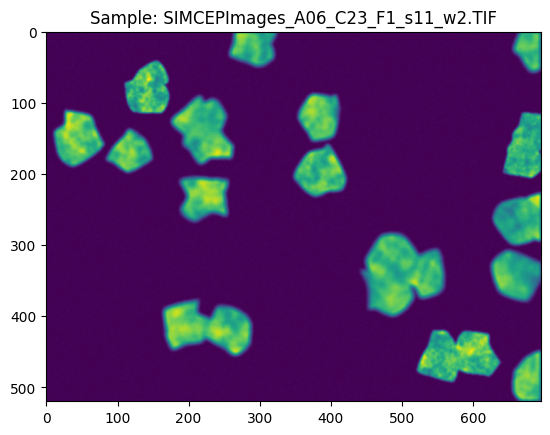

Image Shape: (520, 696)
Max Pixel Value: 222
Min Pixel Value: 0


In [ ]:
from skimage.io import imread
import matplotlib.pyplot as plt
import os

# 1. Define the filename
sample_image = 'SIMCEPImages_A06_C23_F1_s11_w2.TIF'

# 2. Use our image_dir variable instead of the Kaggle path
path_image = os.path.join(image_dir, sample_image)

# 3. Read the image using skimage
image = imread(path_image)

# 4. Display the image
plt.imshow(image)
plt.title(f"Sample: {sample_image}")
plt.show()

# 5. Print some stats to verify it loaded correctly
print(f"Image Shape: {image.shape}")
print(f"Max Pixel Value: {image.max()}")
print(f"Min Pixel Value: {image.min()}")

In [ ]:
# Get lists of images and their masks.
image_id_list = list(df_masks['image_id'])
mask_id_list = list(df_masks['mask_id'])
test_id_list = list(df_test['image_id'])

# Create empty arrays

X_train = np.zeros((len(image_id_list), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)

Y_train = np.zeros((len(image_id_list), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool)

X_test = np.zeros((NUM_TEST_IMAGES, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)

In [ ]:
# X_train
for i, image_id in enumerate(image_id_list):

    # Changed only the path part to use our kagglehub directory
    path_image = os.path.join(image_dir, image_id)

    # read the image using skimage
    image = imread(path_image)

    # resize the image
    image = resize(image, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)

    # use np.expand dims to add a channel axis so the shape becomes (IMG_HEIGHT, IMG_WIDTH, 1)
    image = np.expand_dims(image, axis=-1)

    # insert the image into X_train
    X_train[i] = image

# Check shape after the loop
print(X_train.shape)

(1190, 128, 128, 1)


In [ ]:
# Y_train
for i, mask_id in enumerate(mask_id_list):

    # Changed only the path part to use our kagglehub directory
    path_mask = os.path.join(mask_dir, mask_id)

    # read the image using skimage
    mask = imread(path_mask)

    # resize the image
    mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)

    # use np.expand dims to add a channel axis so the shape becomes (IMG_HEIGHT, IMG_WIDTH, 1)
    mask = np.expand_dims(mask, axis=-1)

    # insert the image into Y_train
    Y_train[i] = mask

# Check shape after the loop
print(Y_train.shape)

(1190, 128, 128, 1)


In [ ]:
# X_test
for i, image_id in enumerate(test_id_list):

    # Changed only the path part to use our kagglehub directory
    path_image = os.path.join(image_dir, image_id)

    # read the image using skimage
    image = imread(path_image)

    # resize the image
    image = resize(image, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)

    # use np.expand dims to add a channel axis so the shape becomes (IMG_HEIGHT, IMG_WIDTH, 1)
    image = np.expand_dims(image, axis=-1)

    # insert the image into X_test
    X_test[i] = image

# Check shape after the loop
print(X_test.shape)

(10, 128, 128, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Dropout, Lambda, Conv2D,
                                     Conv2DTranspose, MaxPooling2D, concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

In [ ]:
inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

s = Lambda(lambda x: x / 255) (inputs)

c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (s)
c1 = Dropout(0.1) (c1)
c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
p1 = MaxPooling2D((2, 2)) (c1)

c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
c2 = Dropout(0.1) (c2)
c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
p2 = MaxPooling2D((2, 2)) (c2)

c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
c3 = Dropout(0.2) (c3)
c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3)
p3 = MaxPooling2D((2, 2)) (c3)

c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p3)
c4 = Dropout(0.2) (c4)
c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c4)
p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p4)
c5 = Dropout(0.3) (c5)
c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c5)

u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same') (c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u6)
c6 = Dropout(0.2) (c6)
c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c6)

u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same') (c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u7)
c7 = Dropout(0.2) (c7)
c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c7)

u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same') (c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u8)
c8 = Dropout(0.1) (c8)
c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c8)

u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same') (c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u9)
c9 = Dropout(0.1) (c9)
c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)

model = Model(inputs=[inputs], outputs=[outputs])

model.compile(optimizer='adam', loss='binary_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
filepath = "model.h5"

earlystopper = EarlyStopping(patience=5, verbose=1)

checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1,
                             save_best_only=True, mode='min')

callbacks_list = [earlystopper, checkpoint]

history = model.fit(X_train, Y_train, validation_split=0.1, batch_size=16, epochs=50,
                    callbacks=callbacks_list)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2064
Epoch 1: val_loss improved from None to 0.03787, saving model to model.h5



Epoch 1: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 0.0972 - val_loss: 0.0379
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0373
Epoch 2: val_loss improved from 0.03787 to 0.02872, saving model to model.h5



Epoch 2: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - loss: 0.0352 - val_loss: 0.0287
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0296
Epoch 3: val_loss improved from 0.02872 to 0.02443, saving model to model.h5



Epoch 3: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - loss: 0.0295 - val_loss: 0.0244
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0268
Epoch 4: val_loss improved from 0.02443 to 0.02324, saving model to model.h5



Epoch 4: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 0.0266 - val_loss: 0.0232
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0253
Epoch 5: val_loss improved from 0.02324 to 0.02121, saving model to model.h5


...


Epoch 20: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - loss: 0.0150 - val_loss: 0.0135
Epoch 21/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0144
Epoch 21: val_loss did not improve from 0.01346
67/67 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0146 - val_loss: 0.0143
Epoch 22/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0142
Epoch 22: val_loss improved from 0.01346 to 0.01305, saving model to model.h5



Epoch 22: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - loss: 0.0142 - val_loss: 0.0131
Epoch 23/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0138
Epoch 23: val_loss did not improve from 0.01305
67/67 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0138 - val_loss: 0.0135
Epoch 24/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0130
Epoch 24: val_loss improved from 0.01305 to 0.01289, saving model to model.h5



Epoch 24: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 0.0134 - val_loss: 0.0129
Epoch 25/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0135
Epoch 25: val_loss improved from 0.01289 to 0.01233, saving model to model.h5



Epoch 25: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - loss: 0.0131 - val_loss: 0.0123
Epoch 26/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0127
Epoch 26: val_loss did not improve from 0.01233
67/67 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 0.0128 - val_loss: 0.0133
Epoch 27/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0122
Epoch 27: val_loss did not improve from 0.01233
67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - loss: 0.0123 - val_loss: 0.0137
Epoch 28/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0118
Epoch 28: val_loss did not improve from 0.01233
67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - loss: 0.0120 - val_loss: 0.0129
Epoch 29/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0116
Epoch 29: val_loss improved from 0.01233 to 0.01207, saving model to model.h5



Epoch 29: finished saving model to model.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 0.0118 - val_loss: 0.0121
Epoch 30/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0115
Epoch 30: val_loss did not improve from 0.01207
67/67 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - loss: 0.0114 - val_loss: 0.0127
Epoch 31/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0109
Epoch 31: val_loss did not improve from 0.01207
67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - loss: 0.0111 - val_loss: 0.0129
Epoch 32/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0108
Epoch 32: val_loss did not improve from 0.01207
67/67 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - loss: 0.0108 - val_loss: 0.0126
Epoch 33/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0106
Epoch 33: val_loss did not improve from 0.01207
67/67 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - loss: 0.0105 - val_loss: 0.0129
Epoch 34/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0102
Epoch 34: val_loss did not improve from 0.01207
67/67 ━━━━━━━━━━━━━━

In [ ]:
# Make a prediction

# use the best epoch
model.load_weights('model.h5')

test_preds = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


In [ ]:
# Threshold the predictions

preds_test_thresh = (test_preds >= 0.5).astype(np.uint8)

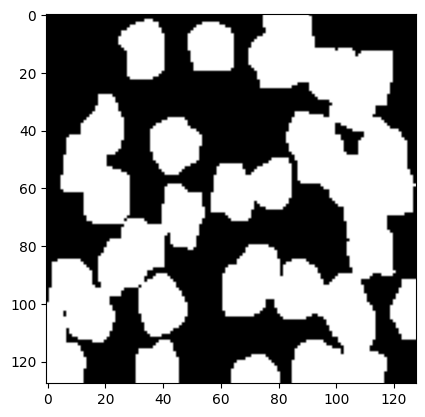

In [ ]:
# Display a thresholded mask

test_img = preds_test_thresh[5, :, :, 0]

plt.imshow(test_img, cmap='gray')

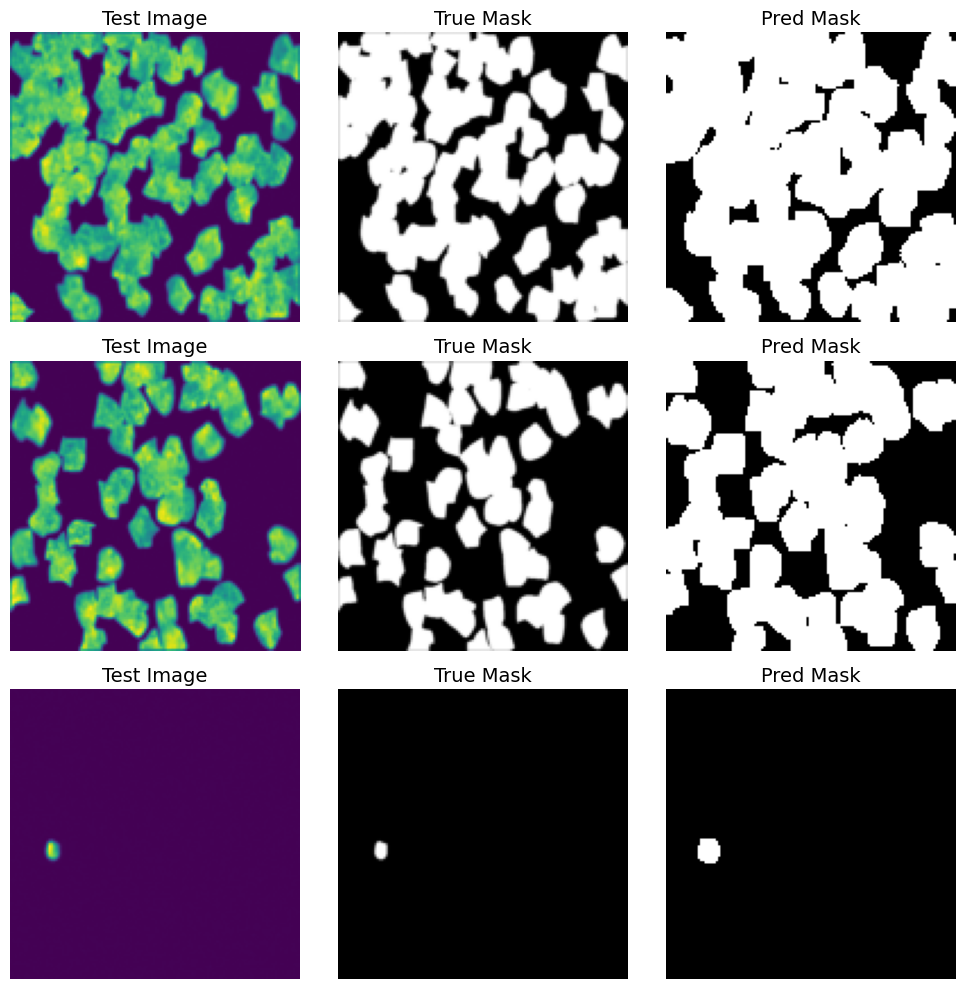

In [ ]:
# set up the canvas for the subplots
plt.figure(figsize=(10,10))

# == row 1 ==

# image
plt.subplot(3,3,1)
test_image = X_test[1, :, :, 0]
plt.imshow(test_image)
plt.title('Test Image', fontsize=14)
plt.axis('off')

# true mask
plt.subplot(3,3,2)
mask_id = df_test.iloc[1]['mask_id'] # Use iloc for safer indexing
# Path corrected below
path_mask = os.path.join(mask_dir, mask_id)
mask = imread(path_mask)
mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
plt.imshow(mask, cmap='gray')
plt.title('True Mask', fontsize=14)
plt.axis('off')

# predicted mask
plt.subplot(3,3,3)
test_mask = preds_test_thresh[1, :, :, 0]
plt.imshow(test_mask, cmap='gray')
plt.title('Pred Mask', fontsize=14)
plt.axis('off')


# == row 2 ==

# image
plt.subplot(3,3,4)
test_image = X_test[2, :, :, 0]
plt.imshow(test_image)
plt.title('Test Image', fontsize=14)
plt.axis('off')

# true mask
plt.subplot(3,3,5)
mask_id = df_test.iloc[2]['mask_id']
# Path corrected below
path_mask = os.path.join(mask_dir, mask_id)
mask = imread(path_mask)
mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
plt.imshow(mask, cmap='gray')
plt.title('True Mask', fontsize=14)
plt.axis('off')

# predicted mask
plt.subplot(3,3,6)
test_mask = preds_test_thresh[2, :, :, 0]
plt.imshow(test_mask, cmap='gray')
plt.title('Pred Mask', fontsize=14)
plt.axis('off')

# == row 3 ==

# image
plt.subplot(3,3,7)
test_image = X_test[3, :, :, 0]
plt.imshow(test_image)
plt.title('Test Image', fontsize=14)
plt.axis('off')

# true mask
plt.subplot(3,3,8)
mask_id = df_test.iloc[3]['mask_id']
# Path corrected below
path_mask = os.path.join(mask_dir, mask_id)
mask = imread(path_mask)
mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
plt.imshow(mask, cmap='gray')
plt.title('True Mask', fontsize=14)
plt.axis('off')

# predicted mask
plt.subplot(3,3,9)
test_mask = preds_test_thresh[3, :, :, 0]
plt.imshow(test_mask, cmap='gray')
plt.title('Pred Mask', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# MODEL EVALUATION (Paste this at the end)
# ==========================================

# 1. First, we need to build the Y_test array (Ground Truth Masks)
# since it wasn't created earlier in the script.
Y_test = np.zeros((NUM_TEST_IMAGES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

for i, mask_id in enumerate(list(df_test['mask_id'])):
    # Use the same mask directory from earlier
    path_mask = os.path.join(mask_dir, mask_id)

    # Read, resize, and expand dimensions just like Y_train
    mask = imread(path_mask)
    mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    mask = np.expand_dims(mask, axis=-1)

    Y_test[i] = mask

# 2. Convert arrays to boolean (True/False) for logical comparisons
y_true_bool = Y_test.astype(np.bool_)
y_pred_bool = preds_test_thresh.astype(np.bool_)

# 3. Flatten the arrays to 1D to compare pixel by pixel
y_true_flat = y_true_bool.flatten()
y_pred_flat = y_pred_bool.flatten()

# 4. Calculate True Positives, False Positives, False Negatives, True Negatives
TP = np.sum(y_true_flat & y_pred_flat)     # Model predicted cell, actually cell
FP = np.sum((~y_true_flat) & y_pred_flat)  # Model predicted cell, actually background
FN = np.sum(y_true_flat & (~y_pred_flat))  # Model predicted background, actually cell
TN = np.sum((~y_true_flat) & (~y_pred_flat)) # Model predicted background, actually background

# 5. Calculate Metrics
pixel_accuracy = (TP + TN) / (TP + TN + FP + FN)

# Prevent division by zero errors
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

# F1 Score is mathematically equivalent to the Dice Coefficient in this context
f1_score = (2 * TP) / ((2 * TP) + FP + FN) if ((2 * TP) + FP + FN) > 0 else 0.0

# 6. Print the results
print("\n" + "="*30)
print("     U-NET TEST METRICS")
print("="*30)
print(f"Global Pixel Accuracy : {pixel_accuracy:.4f} ({pixel_accuracy * 100:.2f}%)")
print(f"Precision             : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall                : {recall:.4f}    ({recall * 100:.2f}%)")
print(f"F1 Score (Dice)       : {f1_score:.4f}  ({f1_score * 100:.2f}%)")
print("="*30)


     U-NET TEST METRICS
Global Pixel Accuracy : 0.9950 (99.50%)
Precision             : 0.9952 (99.52%)
Recall                : 0.9940    (99.40%)
F1 Score (Dice)       : 0.9946  (99.46%)
